# **This notebook is used to train a model that recommends similar games for the Media Logger app.**

# Setup

In [1]:
# import all required lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

import pickle


In [2]:
# lets read the data from out json file in to a data frame
games_df = pd.read_json("games.json")

In [3]:
games_df.head()

,_id,title,description,averageRating,genre,releaseDate,posterUrl,backdropUrl,isActive,status,platforms,avgPlaytime,developer,youtubeVideoId,__v,createdAt,updatedAt,ageRating
0,68de825e063c7dbcff07c0d8,Hollow Knight: Silksong,Hollow Knight: Silksong is the epic sequel to ...,8.36,"[Action, Adventure, Indie, Platformer]",2025-09-04T00:00:00.000Z,https://images.igdb.com/igdb/image/upload/t_co...,https://media.rawg.io/media/screenshots/79a/79...,True,released,"[Xbox Series S/X, Xbox One, PlayStation 5, Pla...",780.0,Team Cherry,6XGeJwsUP9c,0,2025-10-02T13:47:10.164Z,2025-10-04T16:36:57.444Z,NaN
1,68de82d0063c7dbcff07c0e1,Terraria,Terraria is a 2D action adventure sandbox game...,8.14,"[Action, Indie, Platformer]",2011-05-16T00:00:00.000Z,https://images.igdb.com/igdb/image/upload/t_co...,https://media.rawg.io/media/screenshots/640/64...,True,released,"[Xbox 360, Nintendo 3DS, Xbox One, PlayStation...",900.0,Engine Software,,0,2025-10-02T13:49:04.930Z,2025-10-02T13:49:04.930Z,13.0
2,68de82d0063c7dbcff07c0e6,Horizon Zero Dawn,Horizon Zero Dawn is an experiment. A very imp...,8.56,"[Action, RPG]",2017-02-28T00:00:00.000Z,https://images.igdb.com/igdb/image/upload/t_co...,https://media.rawg.io/media/screenshots/622/62...,True,released,"[PC, PlayStation 4]",660.0,Guerrilla Games,,0,2025-10-02T13:49:04.930Z,2025-10-02T13:49:04.930Z,13.0
3,68de82d0063c7dbcff07c0e7,Metro 2033,Not all post-apocalyptic stories begin in the ...,7.88,"[Action, Shooter]",2010-03-16T00:00:00.000Z,https://images.igdb.com/igdb/image/upload/t_co...,https://media.rawg.io/media/screenshots/b5a/b5...,True,released,"[Xbox 360, PC]",120.0,4A Games,,0,2025-10-02T13:49:04.930Z,2025-10-02T13:49:04.930Z,17.0
4,68de82d0063c7dbcff07c0e2,Dota 2,What used to be an unofficial modded map for t...,6.14,[Action],2013-07-09T00:00:00.000Z,https://images.igdb.com/igdb/image/upload/t_co...,https://media.rawg.io/media/screenshots/7ef/7e...,True,released,"[Linux, PC]",840.0,Valve Software,,0,2025-10-02T13:49:04.930Z,2025-10-02T13:49:04.930Z,NaN


# Data processing

In [4]:
games_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   _id             261 non-null    object 
 1   title           261 non-null    object 
 2   description     261 non-null    object 
 3   averageRating   261 non-null    float64
 4   genre           261 non-null    object 
 5   releaseDate     261 non-null    object 
 6   posterUrl       261 non-null    object 
 7   backdropUrl     261 non-null    object 
 8   isActive        261 non-null    bool   
 9   status          261 non-null    object 
 10  platforms       261 non-null    object 
 11  avgPlaytime     246 non-null    float64
 12  developer       261 non-null    object 
 13  youtubeVideoId  261 non-null    object 
 14  __v             261 non-null    int64  
 15  createdAt       261 non-null    object 
 16  updatedAt       261 non-null    object 
 17  ageRating       206 non-null    flo

lets convert the date to datetime

In [5]:
games_df["releaseDate"] = pd.to_datetime(games_df["releaseDate"] , errors="coerce")
games_df["updatedAt"] = pd.to_datetime(games_df["updatedAt"] , errors="coerce")
games_df["createdAt"] = pd.to_datetime(games_df["createdAt"] , errors="coerce")

In [6]:
games_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   _id             261 non-null    object             
 1   title           261 non-null    object             
 2   description     261 non-null    object             
 3   averageRating   261 non-null    float64            
 4   genre           261 non-null    object             
 5   releaseDate     261 non-null    datetime64[ns, UTC]
 6   posterUrl       261 non-null    object             
 7   backdropUrl     261 non-null    object             
 8   isActive        261 non-null    bool               
 9   status          261 non-null    object             
 10  platforms       261 non-null    object             
 11  avgPlaytime     246 non-null    float64            
 12  developer       261 non-null    object             
 13  youtubeVideoId  261 non-null    obj

# Visualization

## Distribution

lets focus on plotting distribution of all numeric values .

In [7]:
num_columns = games_df.select_dtypes(include='number')
num_columns.columns

Index(['averageRating', 'avgPlaytime', '__v', 'ageRating'], dtype='object')

### Age rating

Text(0.5, 1.0, 'Age rating vs count')

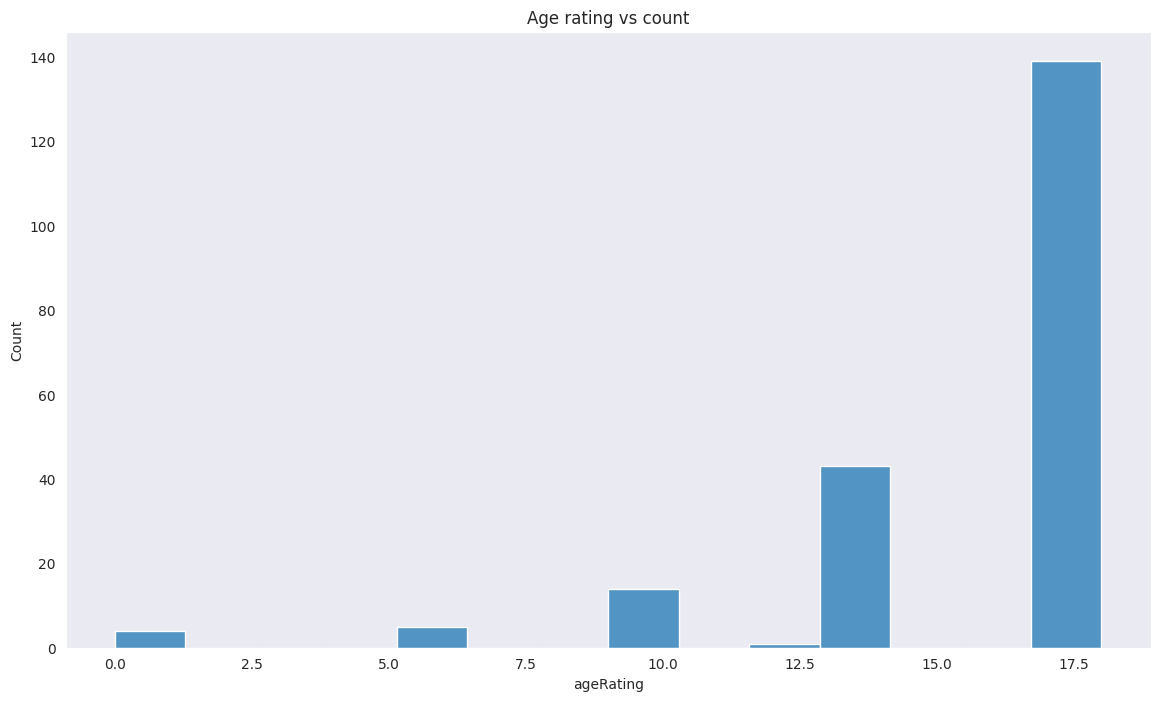

In [8]:
# let plot a hist again the count .
sns.set_style("dark");
plt.figure(figsize=(14, 8));

sns.histplot(x = "ageRating" , data = games_df)
plt.title('Age rating vs count')

Text(0.5, 1.0, 'Age rating vs count')

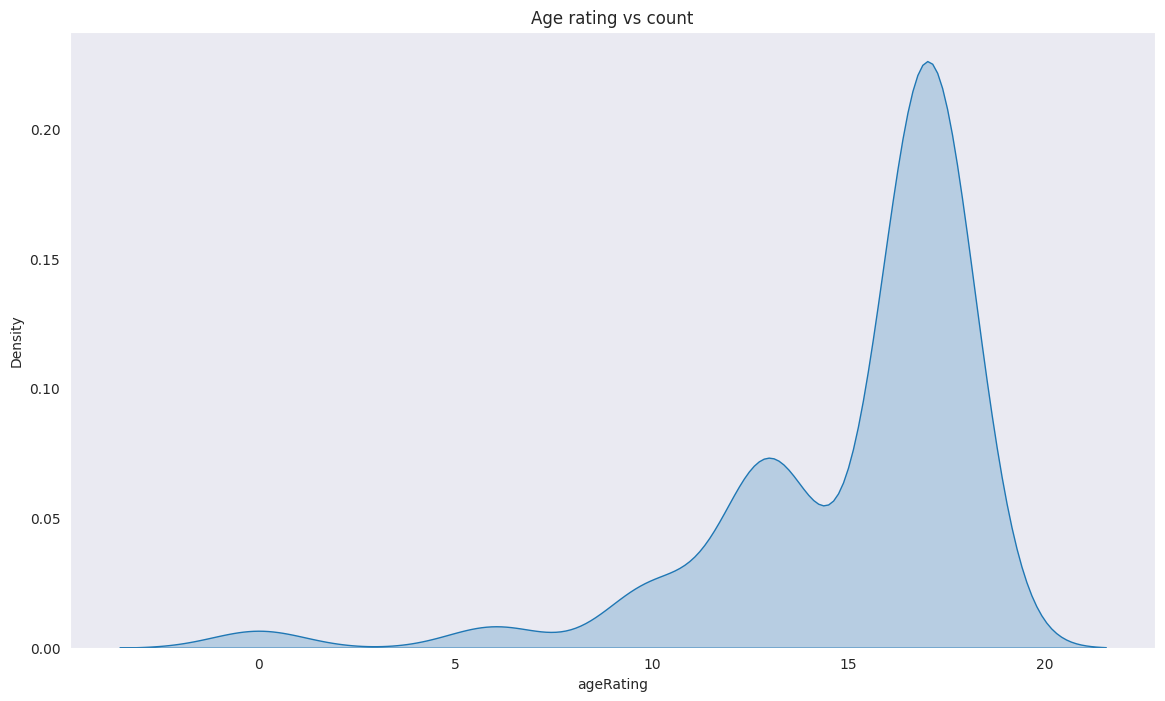

In [9]:
#kde plot
plt.figure(figsize=(14, 8));

sns.kdeplot(x = "ageRating" , data=games_df , fill=True)
plt.title('Age rating vs count')

<Axes: title={'center': 'Age rating vs count'}, xlabel='ageRating', ylabel='count'>

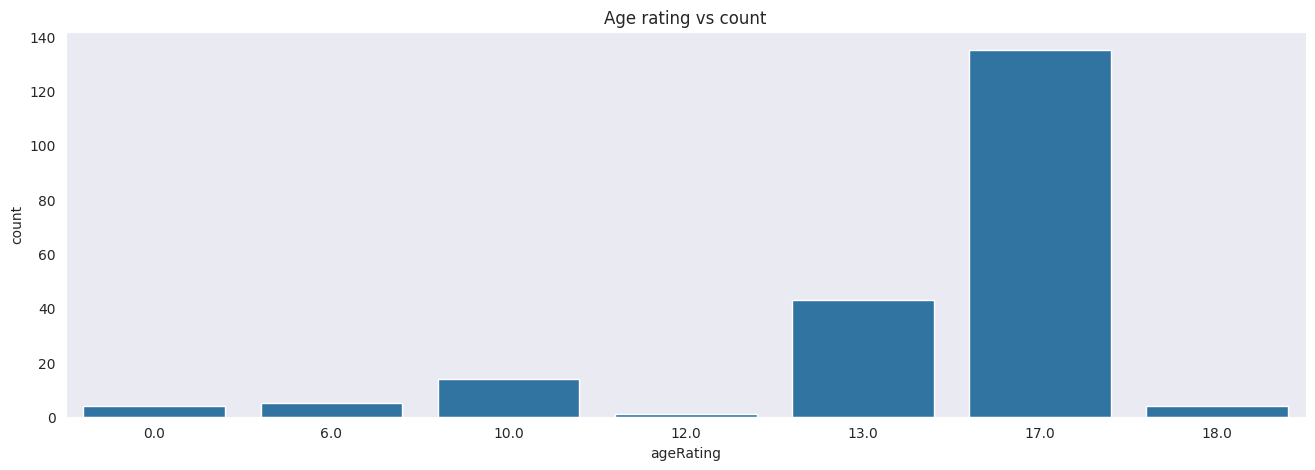

In [10]:
# count plot
plt.figure(figsize=(16 , 5));
plt.title("Age rating vs count")
sns.countplot( x = "ageRating" , data = games_df)

<Axes: title={'center': 'age rating box plot'}, xlabel='ageRating'>

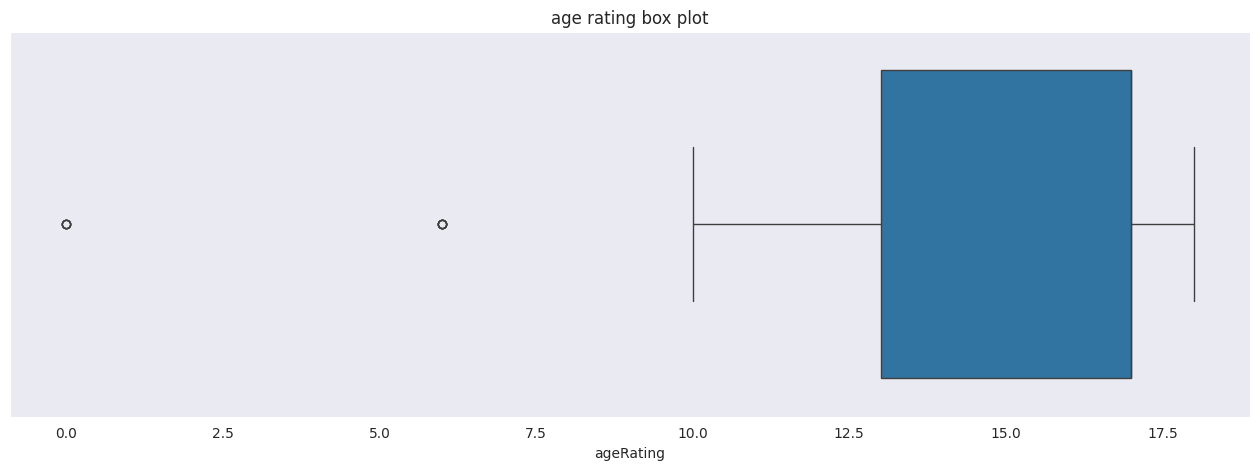

In [11]:
# lets also draw a box plot
plt.figure(figsize=(16 , 5));
plt.title("age rating box plot")
sns.boxplot(x=games_df["ageRating"])

max range at 12- 17

### Average rating

Text(0.5, 1.0, 'Average rating vs count')

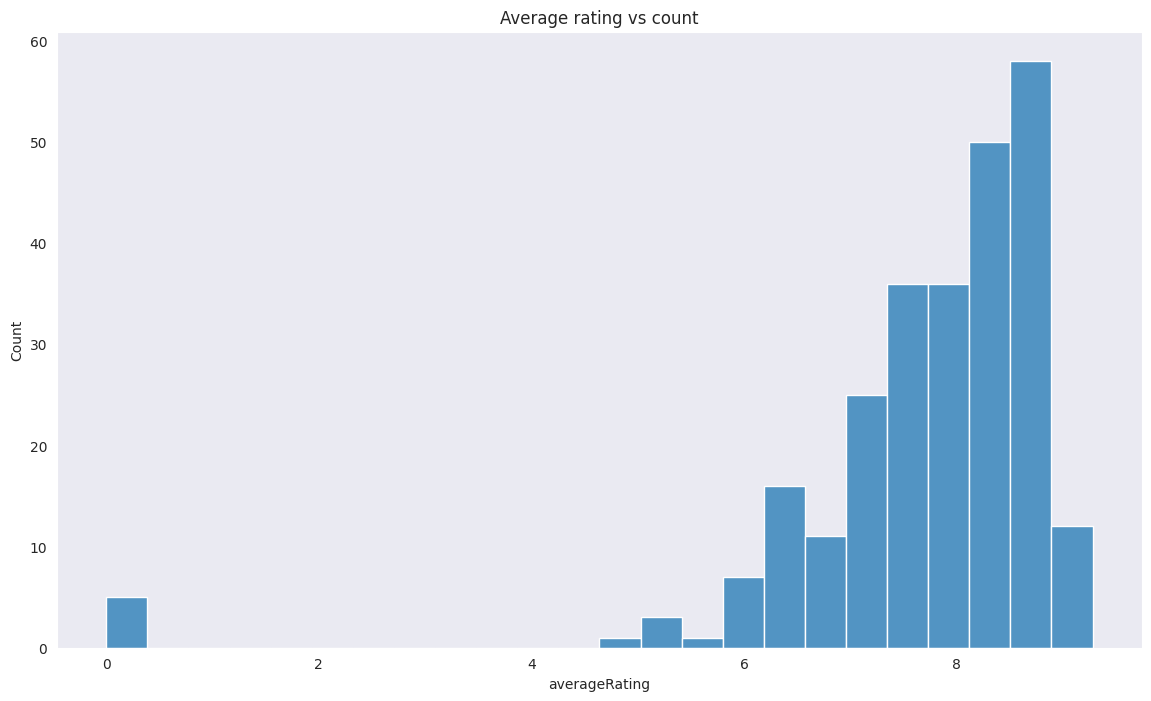

In [12]:
# lets focus on count vs the plot of average rating
plt.figure(figsize=(14, 8));

sns.histplot(x ="averageRating", data = games_df);
plt.title("Average rating vs count")

0 ia same as no rating and will be filtered out on training

<Axes: title={'center': 'average rating box plot'}, xlabel='averageRating'>

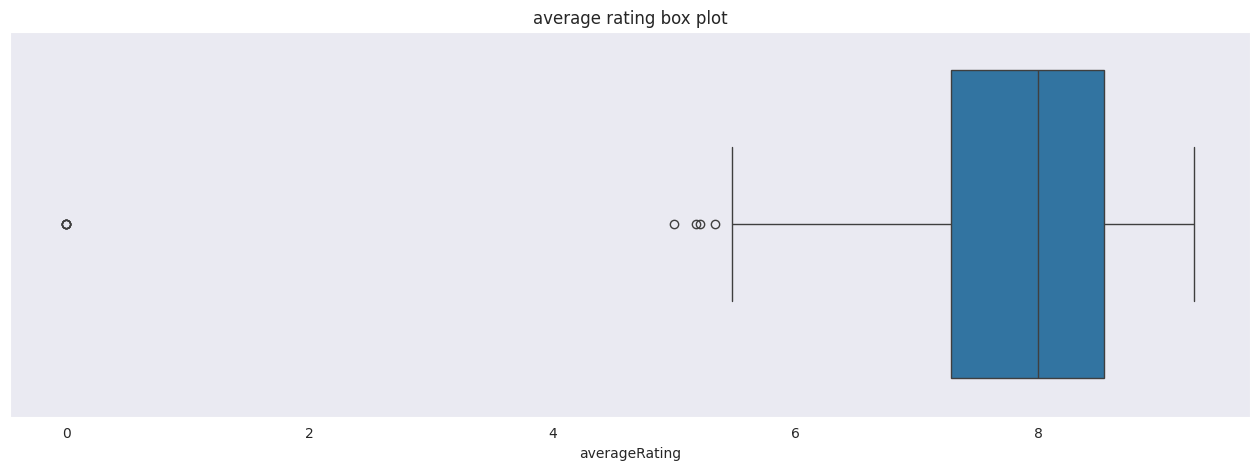

In [13]:
# let drawe the box plot these should not be outliers since we have a limt of 0-10
plt.figure(figsize=(16 , 5));
plt.title("average rating box plot")
sns.boxplot(x=games_df["averageRating"])

### created at

we will only simple draw a kde plot for visulaization , and we will not use this for training

Text(0.5, 1.0, 'created at vs count')

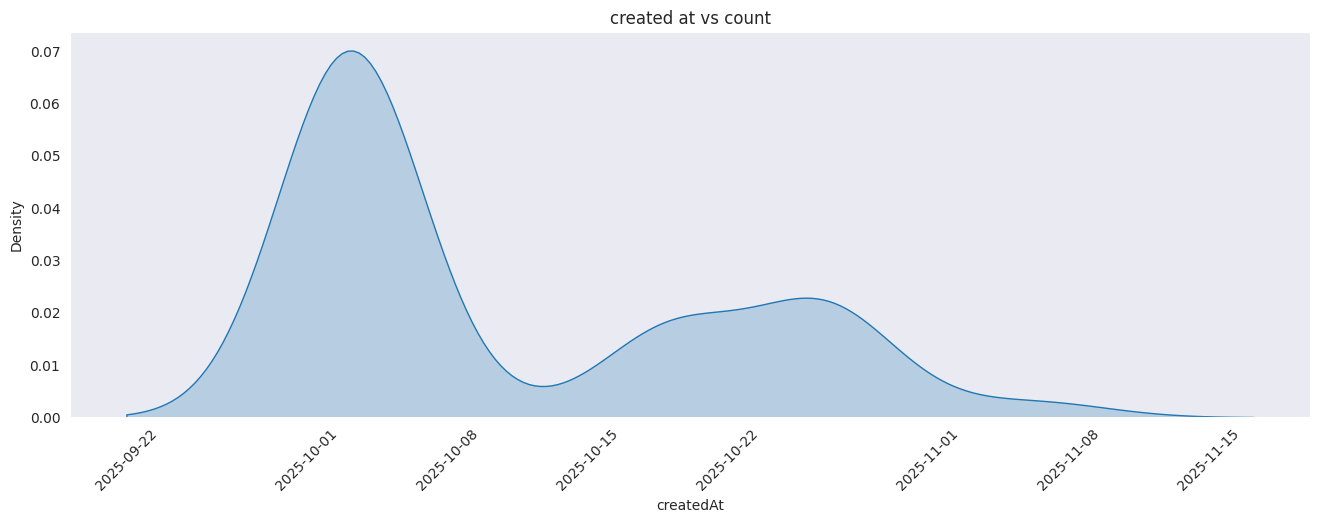

In [14]:
# create a kde plot
plt.figure(figsize=(16 , 5));
sns.kdeplot(x = "createdAt" , data = games_df , fill = True)
plt.xticks(rotation=45)
plt.title("created at vs count")

## Release date

<Axes: title={'center': 'release date  vs count'}, xlabel='releaseDate', ylabel='Count'>

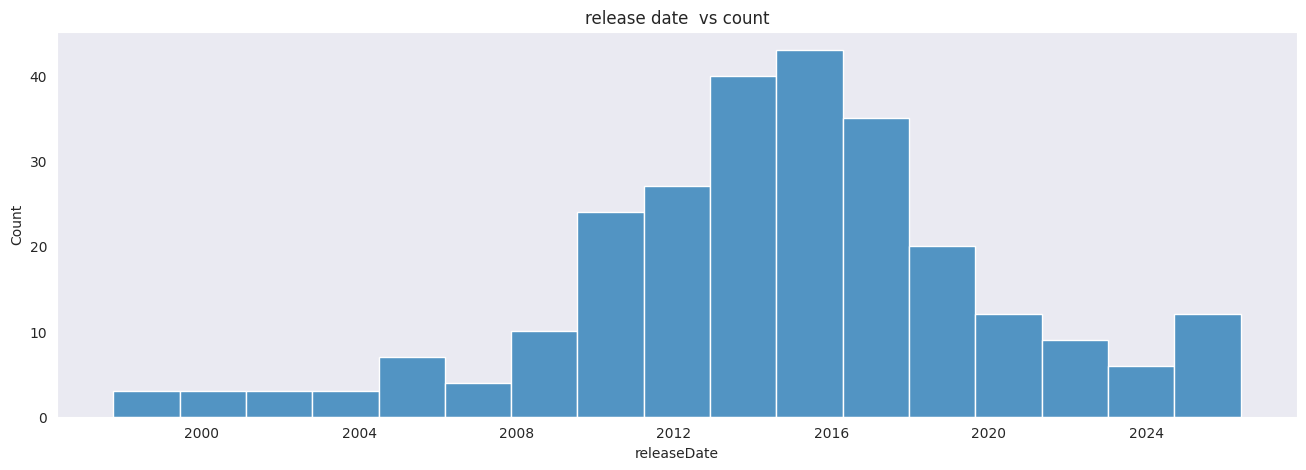

In [15]:
# hist graph for release date vs count
sns.set_style("dark");
plt.figure(figsize=(16 , 5));

plt.title("release date  vs count")
sns.histplot( x = "releaseDate" , data = games_df)

Text(0.5, 1.0, 'release date  vs count')

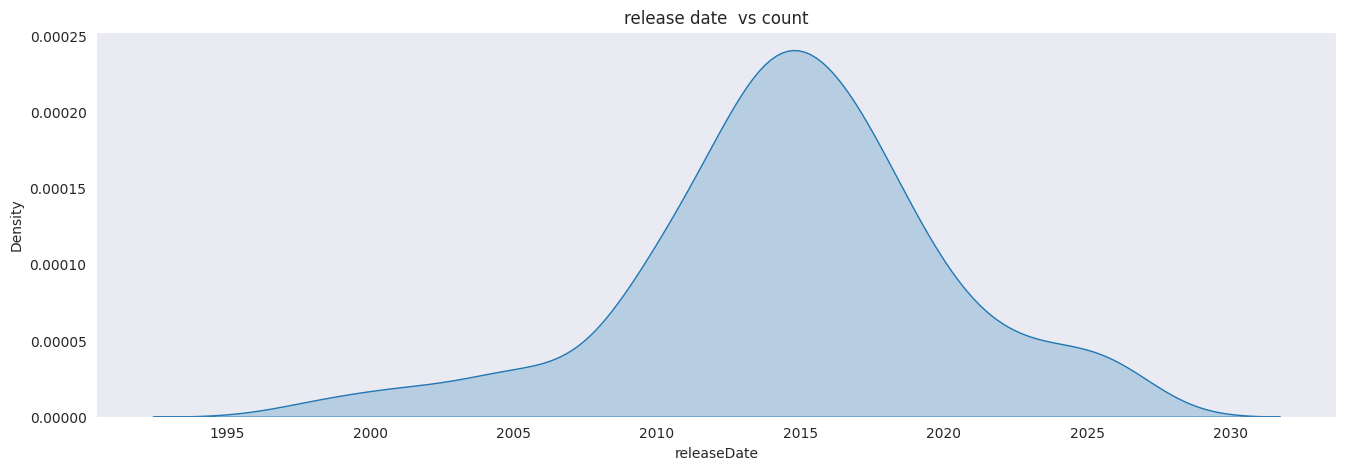

In [16]:
#kde plot
plt.figure(figsize=(16 , 5));
sns.kdeplot(x = "releaseDate" , data = games_df , fill = True)
plt.title("release date  vs count")

<Axes: title={'center': 'release box plot'}, xlabel='releaseDate'>

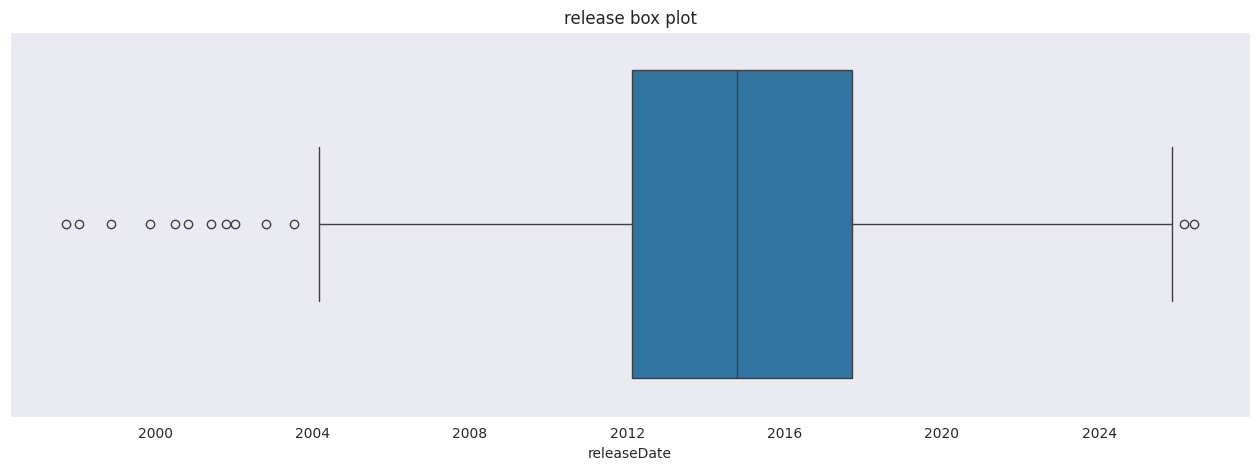

In [17]:
# lets also draw a box plot
plt.figure(figsize=(16 , 5));
plt.title("release box plot")
sns.boxplot(x=games_df["releaseDate"])

we will be imputing any outliers in the date range as per iqr

### Average play time

this can have a wide range .
we are currently storing data in minutes

<Axes: title={'center': 'Average run time vs count '}, xlabel='avgPlaytime', ylabel='Count'>

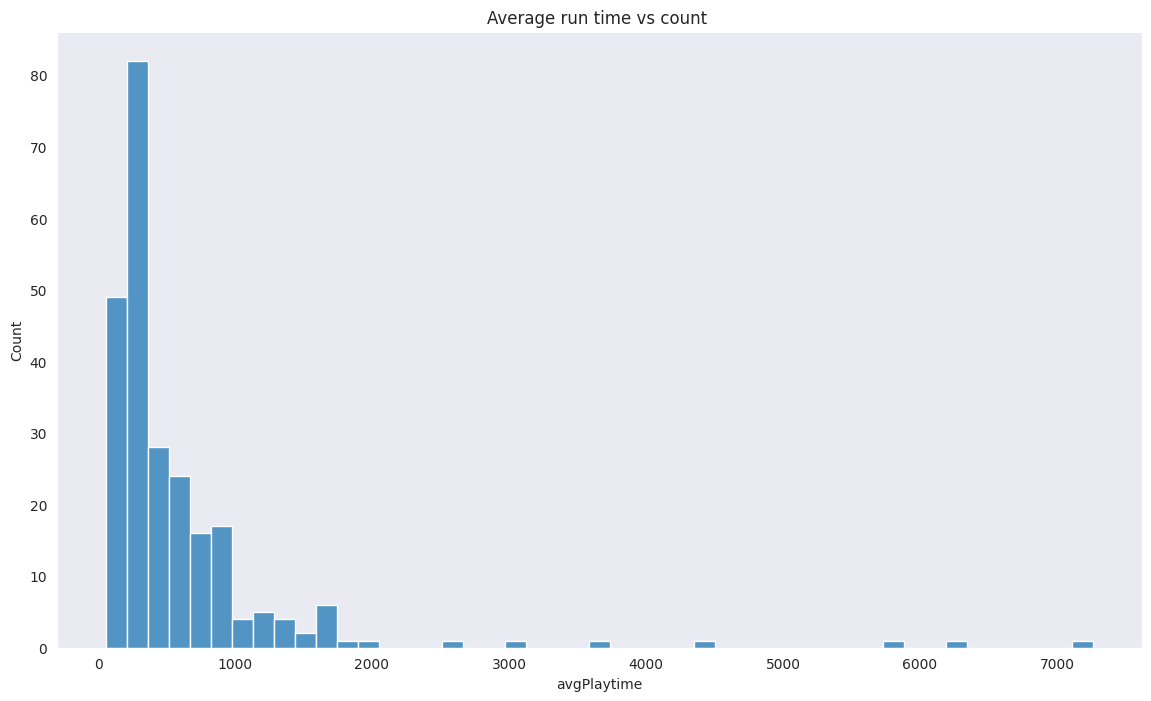

In [18]:
# lets plot hist plot for playtime
plt.figure(figsize=(14, 8));
plt.title("Average run time vs count ")
sns.histplot(x ="avgPlaytime" , data = games_df)

as we can observe there are some at very high play time . they hve to be handled in data cleaning a preocess

<Axes: title={'center': 'play time box plot'}, xlabel='avgPlaytime'>

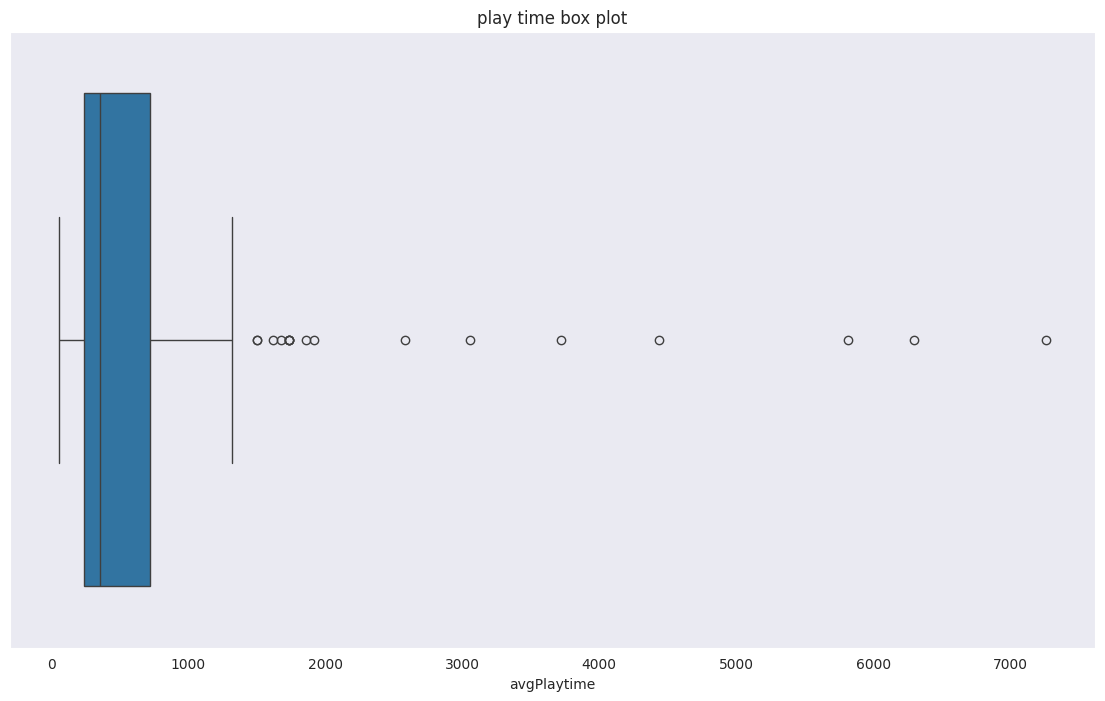

In [19]:
# lets also draw a box plot
plt.figure(figsize=(14 , 8));
plt.title("play time box plot")
sns.boxplot(x= games_df["avgPlaytime"])

## **Categorical Feature Analysis**

lets analyize our categorical data

In [20]:
# list of all the categorical data
cat_columns  = games_df.select_dtypes(include = "object")
cat_columns.columns

Index(['_id', 'title', 'description', 'genre', 'posterUrl', 'backdropUrl',
       'status', 'platforms', 'developer', 'youtubeVideoId'],
      dtype='object')

In [21]:
# let's create a copy of the data for analysis
games_analysis = games_df.copy()

### Genre

In [22]:
# replace the empty array oe missing values with unknown as place holder
games_analysis["genre_filled"] = games_analysis['genre'].apply(lambda x : x if isinstance(x, list) and len(x) > 0 else ["unknown"])

# explode and count includes placeholder
exploded_genre = games_analysis["genre_filled"].explode()
genre_counts = exploded_genre.value_counts()

genre_counts

,count
genre_filled,
Action,209
Adventure,77
RPG,77
Shooter,73
Indie,50
Platformer,18
Simulation,17
Strategy,15
Puzzle,9


action has be tagged a lot  , we can see that only 16 unique tags are used as of now

In [23]:
exploded_genre.unique()

array(['Action', 'Adventure', 'Indie', 'Platformer', 'RPG', 'Shooter',
       'Sports', 'Racing', 'Simulation', 'Puzzle', 'Strategy', 'Fighting',
       'Horror', 'Battle Royale', 'Stealth', 'Survival', 'Open World'],
      dtype=object)

In [24]:
# lets convert this to df to draw plots
genre_df = genre_counts.reset_index()
genre_df.columns = ["genre" , "count"]

genre_df

,genre,count
0,Action,209
1,Adventure,77
2,RPG,77
3,Shooter,73
4,Indie,50
5,Platformer,18
6,Simulation,17
7,Strategy,15
8,Puzzle,9
9,Fighting,8


<Axes: title={'center': 'Genere vs count '}, xlabel='Count', ylabel='Genre'>

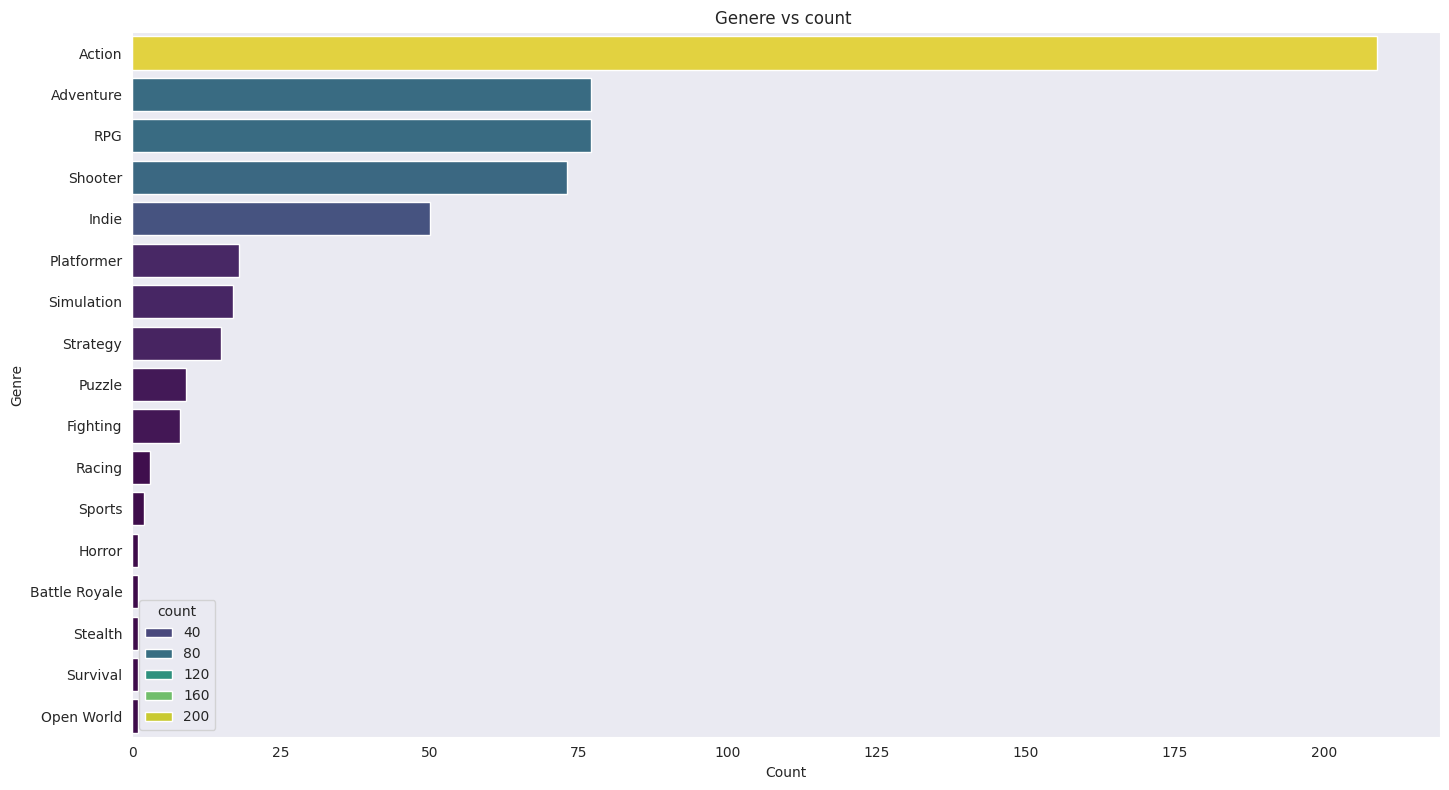

In [25]:
# plot the distribution plot with respect to count
sns.set_style("dark")
plt.figure(figsize=(14, 8));
plt.title("Genere vs count ")
plt.xlabel("Count");
plt.ylabel('Genre')
plt.tight_layout()
sns.barplot(x='count', y='genre', data=genre_df, palette='viridis' , hue="count")

### platforms

In [26]:
# Replace the empty array or the missing values with unknown as place holder
games_analysis["platforms_filled"] = games_analysis["platforms"].apply(lambda x : x  if isinstance(x , list)  and len(x) > 0 else ["unknown"])

# explode and count including the placeholder
exploded_platform = games_analysis["platforms_filled"].explode()
platform_counts = exploded_platform.value_counts()

## convert to df
platform_df = platform_counts.reset_index()
platform_df.columns = ["platform" , 'count']
platform_df

,platform,count
0,PC,249
1,Xbox One,163
2,PlayStation 4,163
3,Xbox 360,82
4,Nintendo Switch,81
5,PlayStation 3,77
6,Linux,72
7,PlayStation 5,50
8,Android,32
9,Xbox Series S/X,31


PC is used the most .

<Axes: title={'center': 'platform vs count '}, xlabel='Count', ylabel='Platfom'>

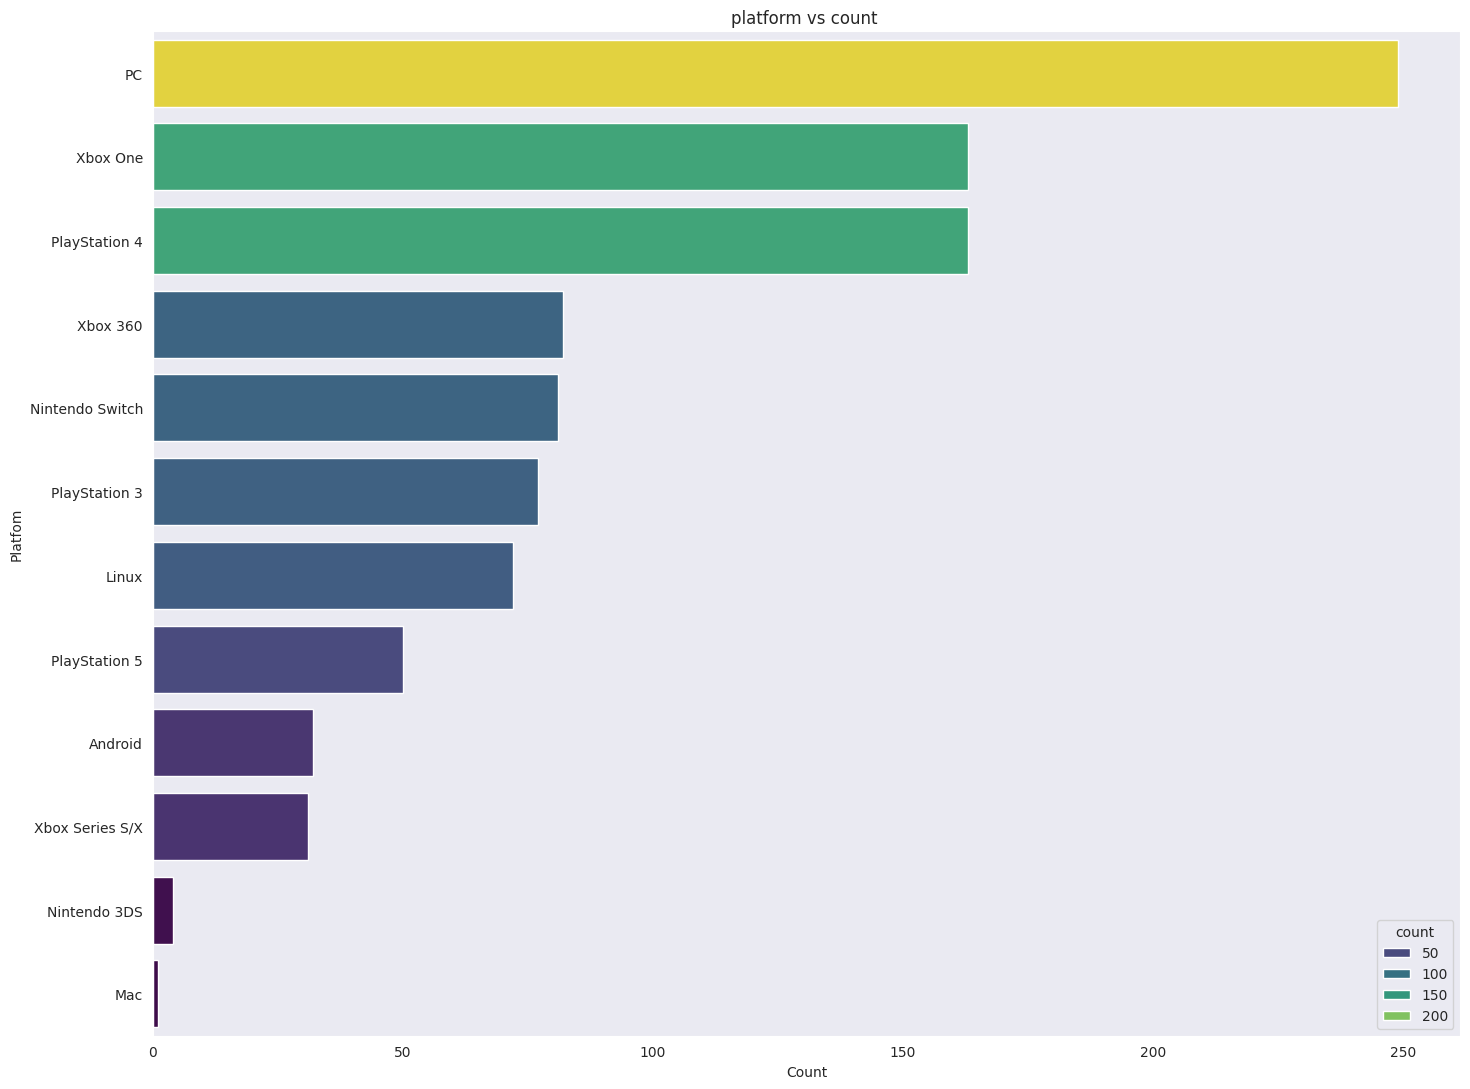

In [27]:
# plot the platform distribution plot with respect to count
sns.set_style("dark")
plt.figure(figsize=(14, 11));
plt.title("platform vs count ")
plt.xlabel("Count");
plt.ylabel('Platfom')
plt.tight_layout()
sns.barplot(x='count', y='platform', data=platform_df, palette='viridis' , hue="count")

### **isActive**

<Axes: xlabel='isActive', ylabel='count'>

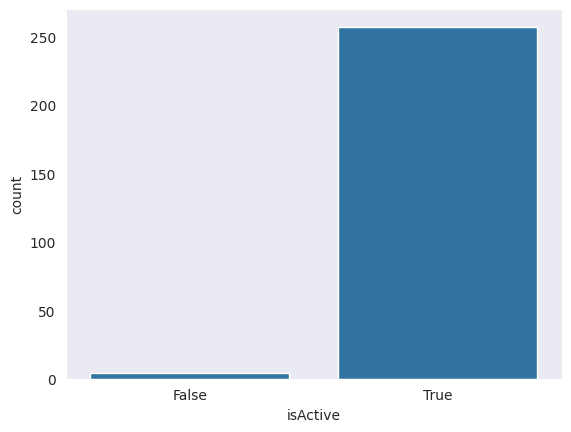

In [28]:
# lest check active and non active
sns.countplot(x= "isActive" , data = games_df )

there are few games set to inactive these will be removed from training .

### Average rating & genre

In [29]:
# explode genre
exploded_genre_rating =  games_analysis.explode("genre")

# lets drop any missing values
exploded_genre_rating = exploded_genre_rating.dropna(subset= ["genre" , "averageRating"])

# group by genere : calculate the count and mean of average rating
genre_stats = exploded_genre_rating.groupby("genre").agg(
    Count = ("genre" ,"size"),
    AvgRating= ("averageRating" , "mean")
).reset_index()

genre_stats

,genre,Count,AvgRating
0,Action,209,7.642584
1,Adventure,77,7.759481
2,Battle Royale,1,7.040000
3,Fighting,8,7.335000
4,Horror,1,6.960000
5,Indie,50,7.738400
6,Open World,1,8.820000
7,Platformer,18,8.153333
8,Puzzle,9,8.000000
9,RPG,77,7.810909


we can se bit of varied avg ratings

<Axes: title={'center': 'genere vs count with averating'}, xlabel='Count', ylabel='genre'>

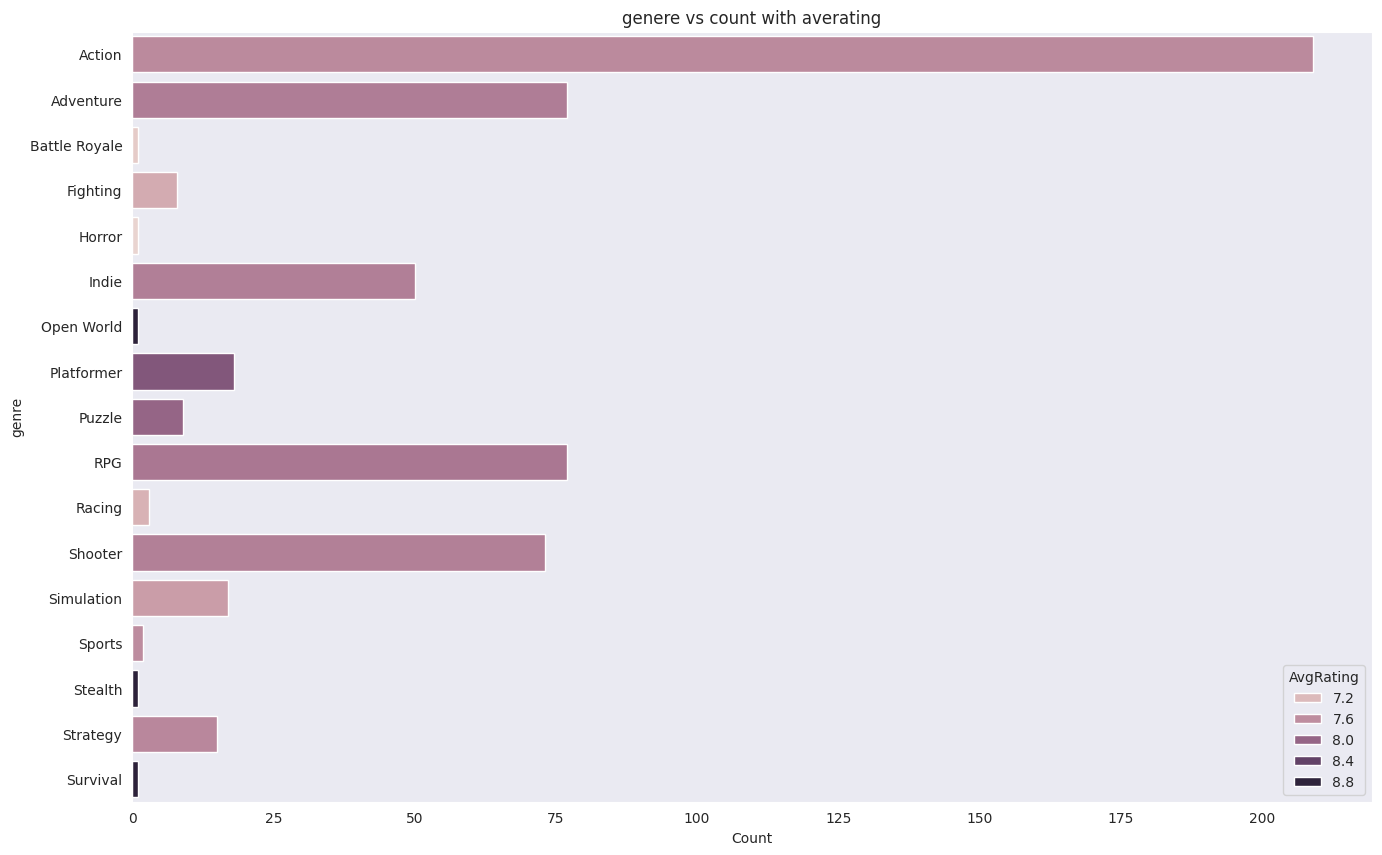

In [30]:
# lets plot a graph
sns.set_style("dark")
plt.figure(figsize=(16, 10));

plt.title("genere vs count with averating")
sns.barplot(x= "Count" , y= "genre" , data = genre_stats , hue= "AvgRating")

open world and survivalgames have most rating

In [32]:
# sort by count
genre_stats = genre_stats.sort_values("Count" , ascending=False)

<Axes: title={'center': 'genere vs count with averating'}, xlabel='Count', ylabel='genre'>

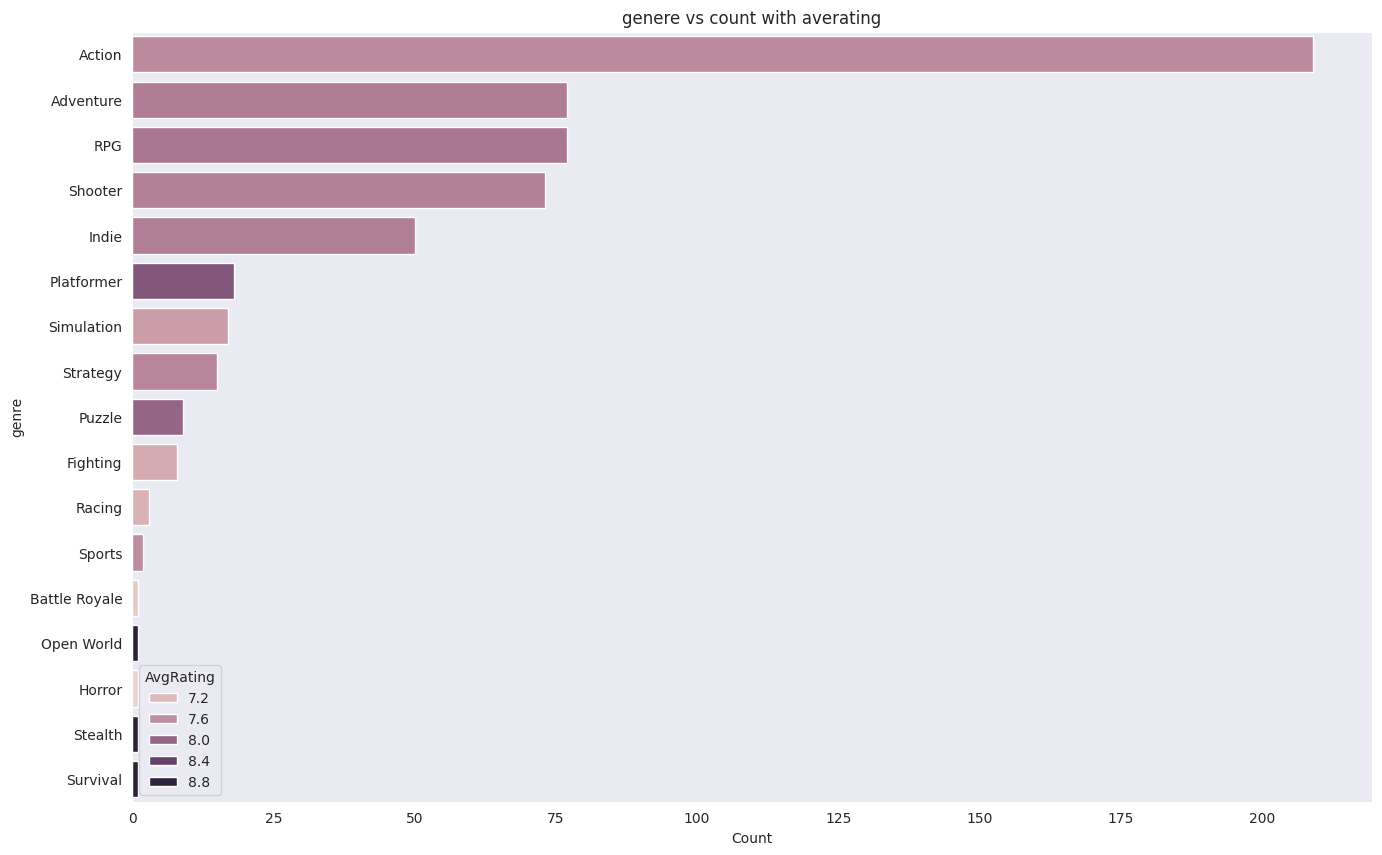

In [33]:
plt.figure(figsize=(16, 10));

plt.title("genere vs count with averating")
sns.barplot(x= "Count" , y= "genre" , data = genre_stats , hue= "AvgRating")

/tmp/ipython-input-3507860723.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data = genre_stats , x = "Count" ,y = "AvgRating"  , size = "Count" , sizes=(100, 1000) , alpha= 0.7 , palette='viridis' )


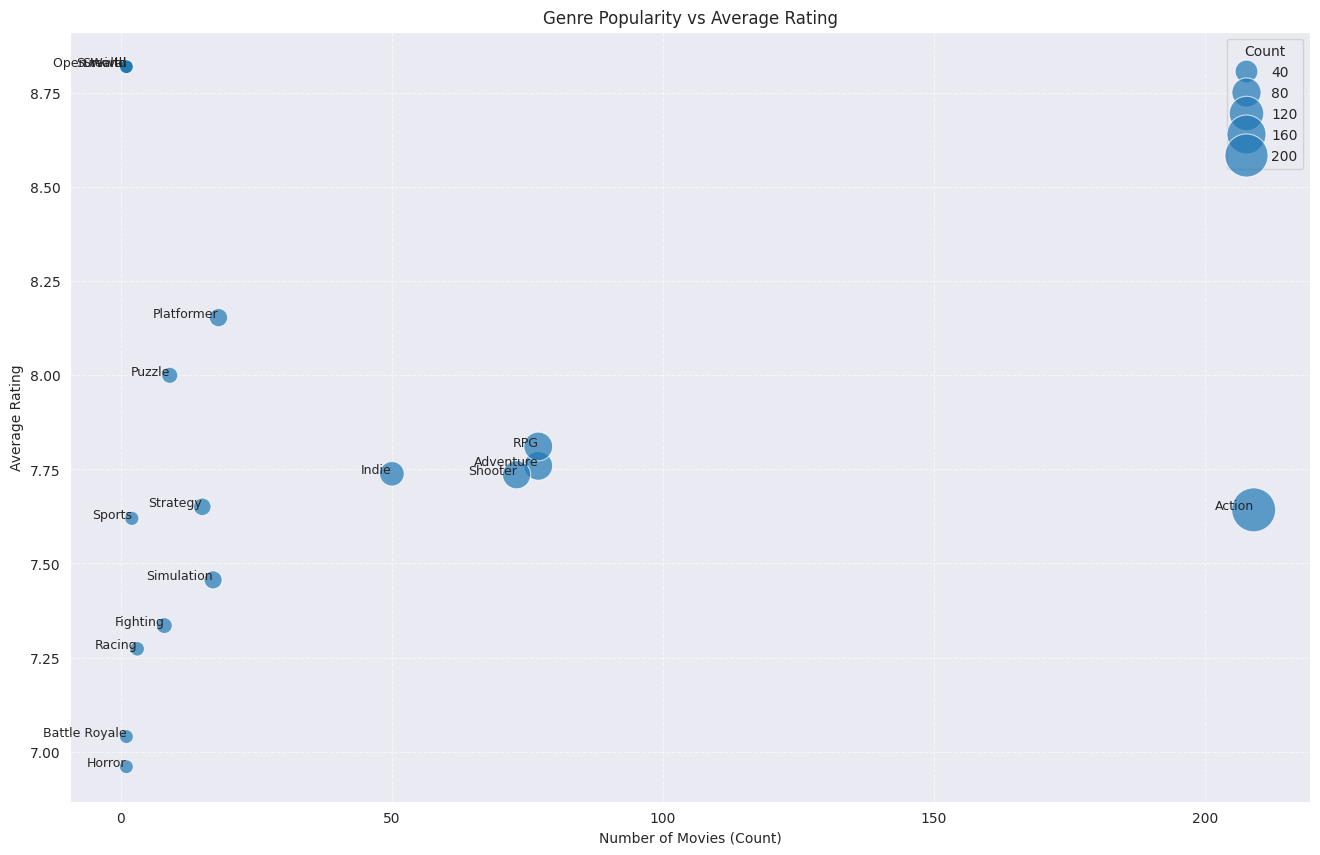

In [34]:
# lest also have a scatter plot  with respect to count and avergae rating on y
plt.figure(figsize=(16, 10));
sns.scatterplot(data = genre_stats , x = "Count" ,y = "AvgRating"  , size = "Count" , sizes=(100, 1000) , alpha= 0.7 , palette='viridis' )
# Label points with genre names for better readability
for i, row in genre_stats.iterrows():
    plt.text(row['Count'], row['AvgRating'], row['genre'], fontsize=9, ha='right')

plt.title('Genre Popularity vs Average Rating')
plt.xlabel('Number of Movies (Count)')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.6)

/tmp/ipython-input-4043459094.py:4: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


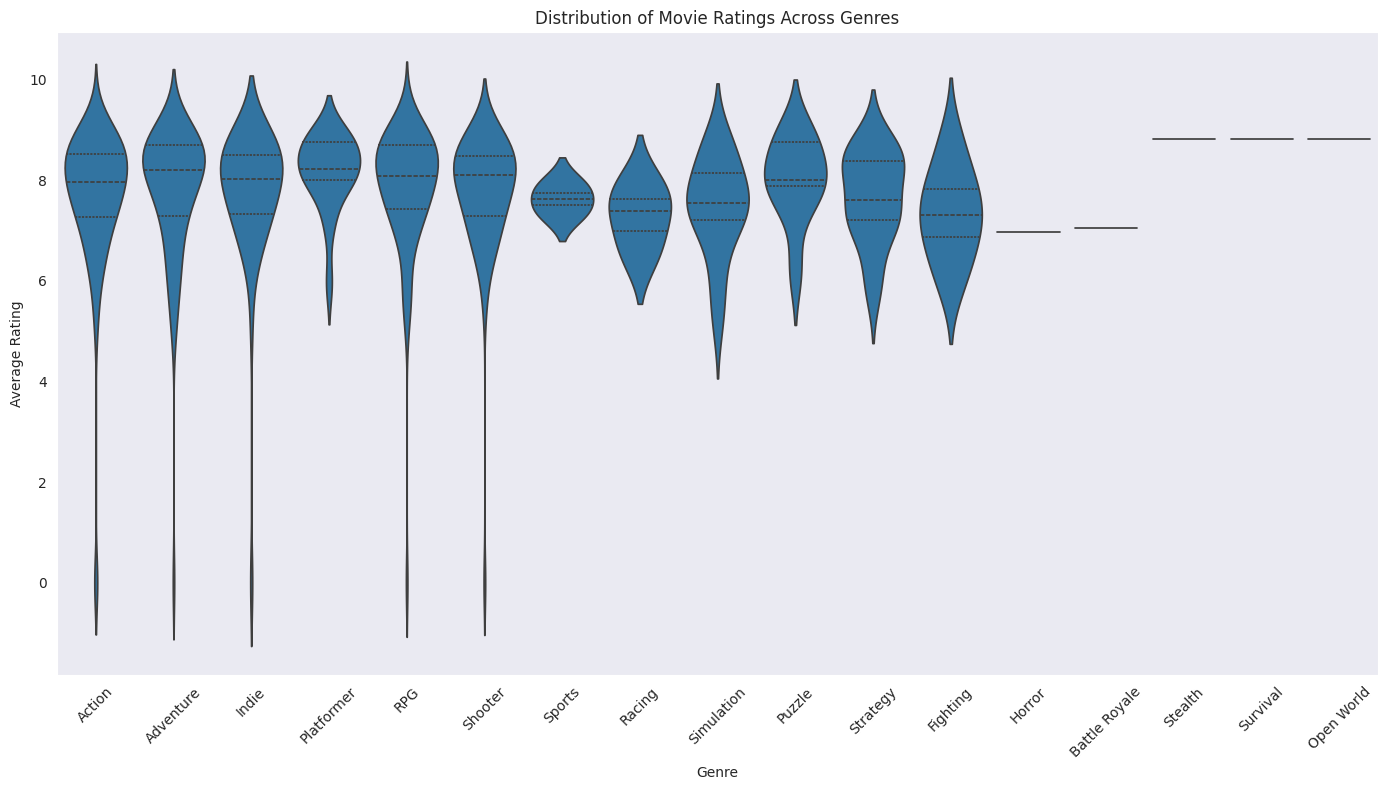

In [35]:
# violin plot

plt.figure(figsize=(14, 8));
sns.violinplot(
    x= "genre",
    y = "averageRating",
    data = exploded_genre_rating,
    inner= "quartile",
    scale= "width"
)

plt.xticks(rotation=45)
plt.title('Distribution of games Ratings Across Genres')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

we can make out theat the averag ewas high for open world and survival since they have very less count .

### Average rating & platforms

In [38]:
# explode platforms
exploded_platform_rating =  games_analysis.explode("platforms")

#lets drop any missing values
exploded_platform_rating= exploded_platform_rating.dropna(subset =["averageRating" , "platforms"])

# group platfoms and cal average ratings
platform_stats = exploded_platform_rating.groupby("platforms").agg(
    Count = ("platforms" ,"size"),
    AvgRating= ("averageRating" , "mean")
).reset_index()

platform_stats


,platforms,Count,AvgRating
0,Android,32,8.048125
1,Linux,72,7.707500
2,Mac,1,7.040000
3,Nintendo 3DS,4,8.190000
4,Nintendo Switch,81,7.972593
5,PC,249,7.747711
6,PlayStation 3,77,7.908052
7,PlayStation 4,163,7.944172
8,PlayStation 5,50,7.761200
9,Xbox 360,82,7.935122


In [41]:
# lets sort by count
platform_stats_sorted = platform_stats.sort_values("Count" , ascending=False)

<Axes: title={'center': 'platform vs count with averating'}, xlabel='Count', ylabel='platforms'>

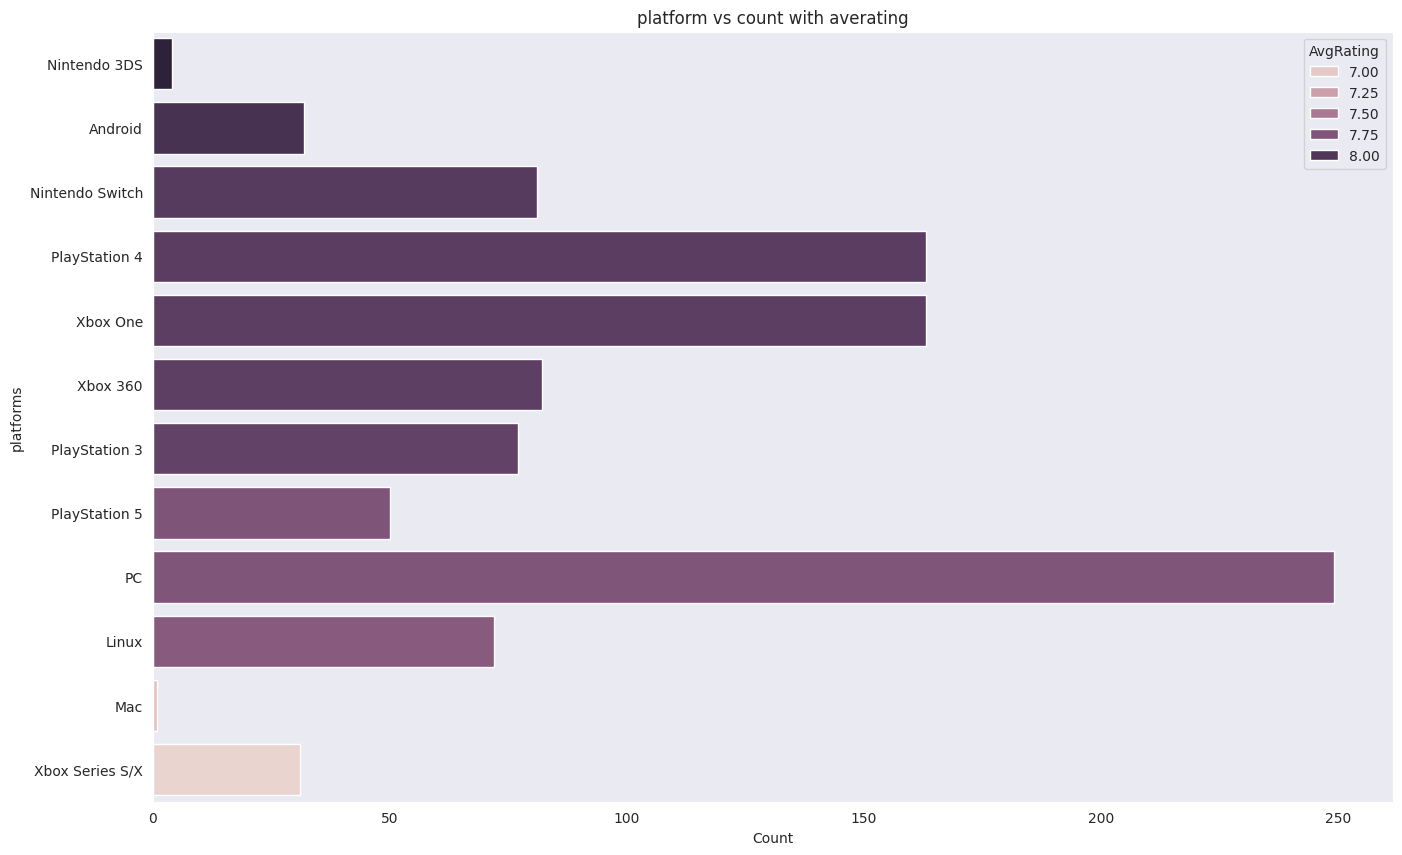

In [46]:
# lets plot the bar graph
sns.set_style("dark")
plt.figure(figsize=(16, 10));

plt.title("platform vs count with averating")
sns.barplot(x= "Count" , y= "platforms" , data = platform_stats_sorted , hue= "AvgRating")

In [44]:
# lets sort by average rating
platform_stats_sorted = platform_stats.sort_values("AvgRating" , ascending=False)

<Axes: title={'center': 'tags vs count with averating'}, xlabel='Count', ylabel='platforms'>

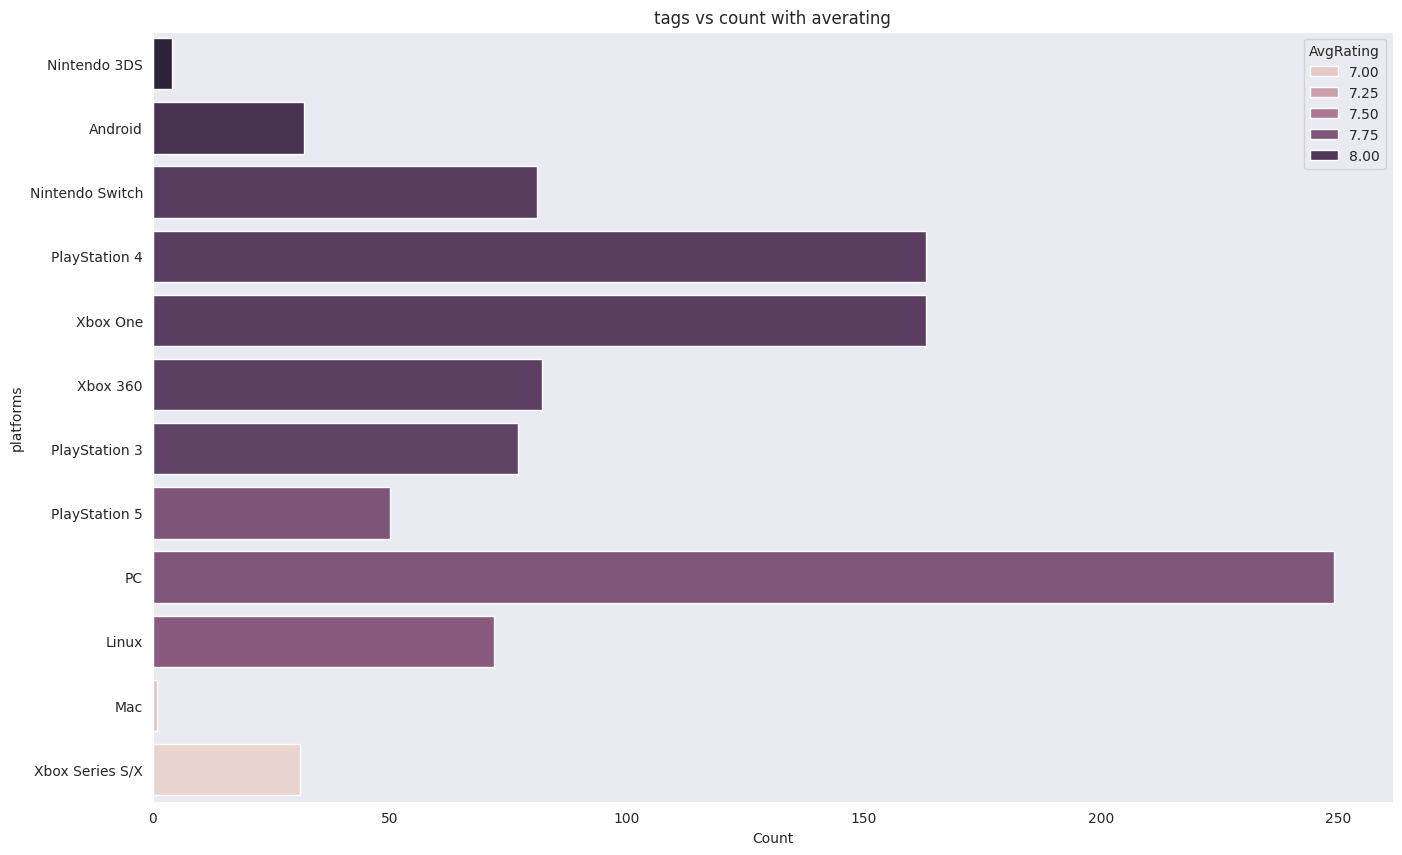

In [45]:
# lets plot the bar graph
sns.set_style("dark")
plt.figure(figsize=(16, 10));

plt.title("platform vs count with averating")
sns.barplot(x= "Count" , y= "platforms" , data = platform_stats_sorted , hue= "AvgRating")

/tmp/ipython-input-3387409236.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data = platform_stats , x = "Count" ,y = "AvgRating"  , size = "Count" , sizes=(100, 1000) , alpha= 0.7 , palette='viridis' )


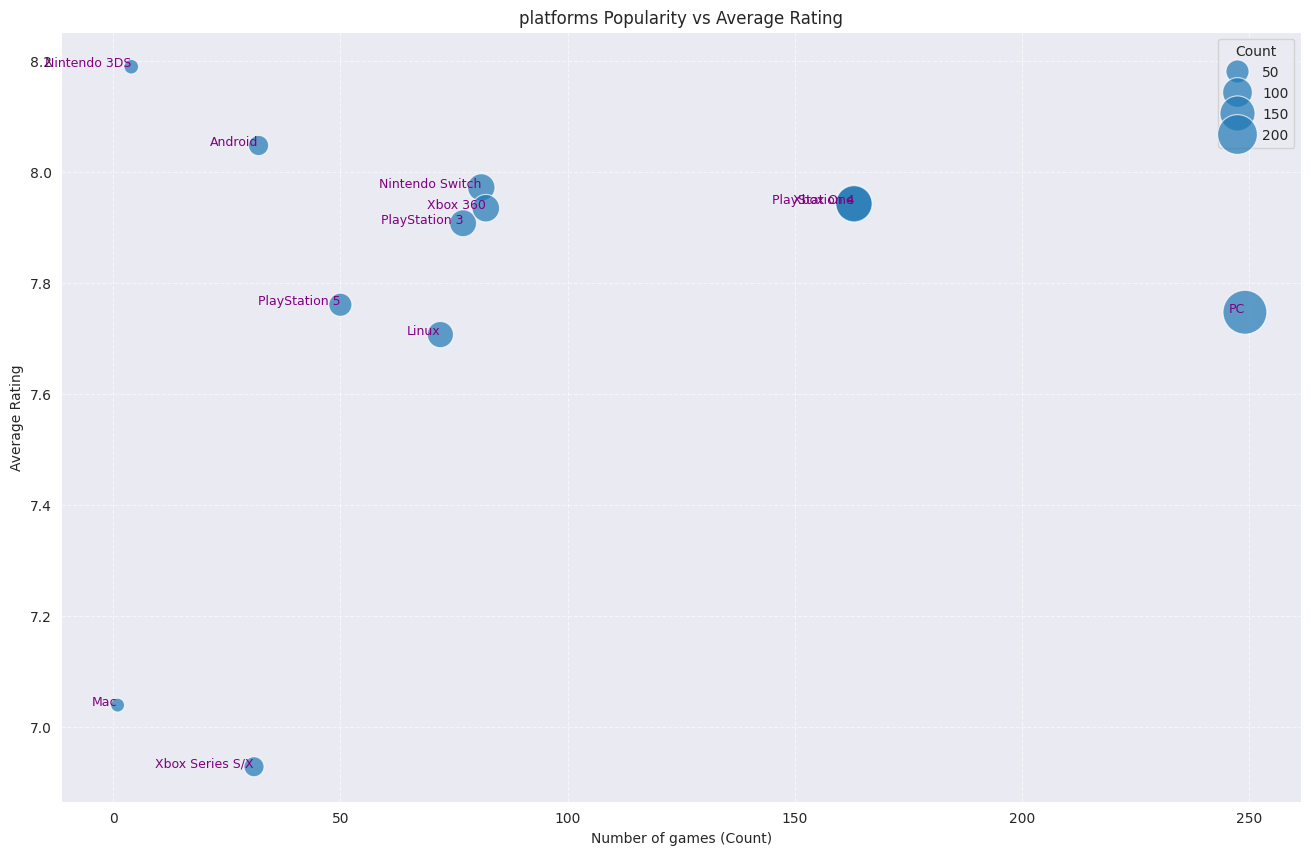

In [49]:
# let get a scatter plot
plt.figure(figsize=(16, 10));
sns.scatterplot(data = platform_stats , x = "Count" ,y = "AvgRating"  , size = "Count" , sizes=(100, 1000) , alpha= 0.7 , palette='viridis' )

# Label points with tags names for better readability
for i, row in platform_stats.head(15).iterrows():
    plt.text(row['Count'], row['AvgRating'], row['platforms'], fontsize=9, ha='right' , color="purple")

plt.title('platforms Popularity vs Average Rating')
plt.xlabel('Number of games (Count)')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.6)

/tmp/ipython-input-1623867833.py:3: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


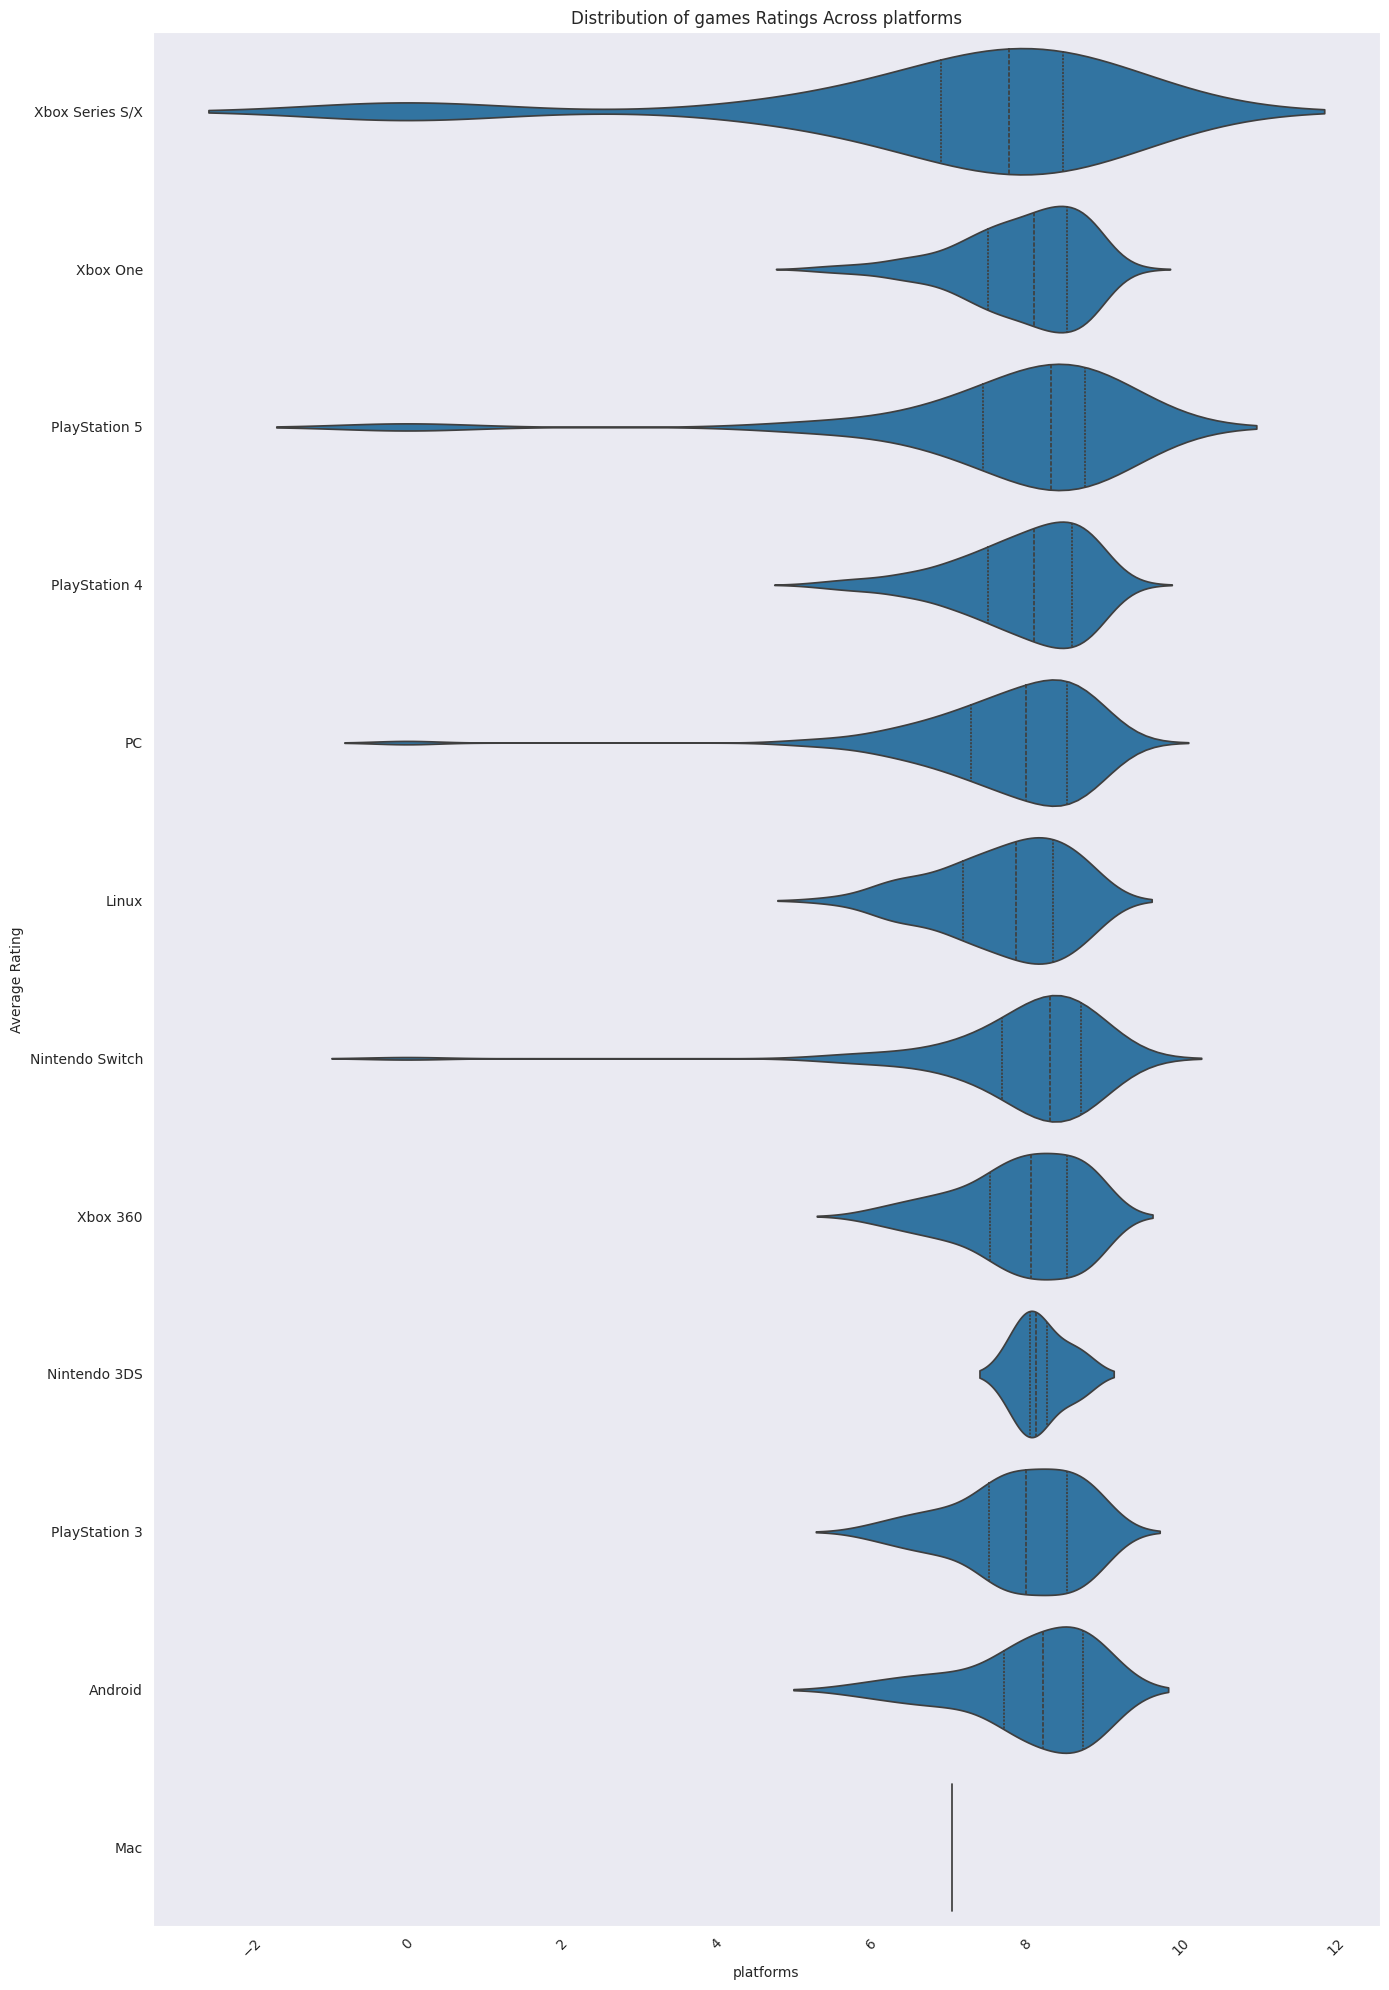

In [50]:
# let also go for a voiline plot for distribution visualization
plt.figure(figsize=(14, 20));
sns.violinplot(
    x= "averageRating",
    y="platforms",
    data = exploded_platform_rating,
    inner= "quartile",
    scale="width"
)

plt.xticks(rotation=45)
plt.title('Distribution of games Ratings Across platforms')
plt.xlabel('platforms')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

### Status

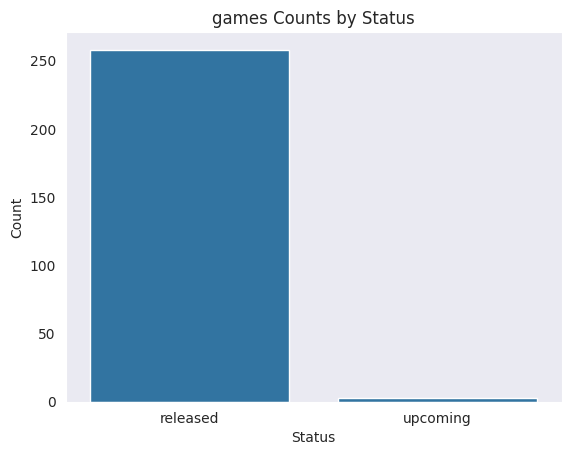

In [52]:
# lest plot count of released and upcomming.
status_counts = games_df['status'].value_counts().reset_index()
status_counts.columns = ['Status', 'Count']

sns.barplot(x='Status', y='Count', data=status_counts)
plt.title('games Counts by Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

we will skip status with respect to count , genere  till we get more counts of upcomming data

### Relationships & Correlations

/tmp/ipython-input-3145757127.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["averageRating"].replace(0, np.nan, inplace=True)
/tmp/ipython-input-3145757127.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

<Axes: title={'center': 'Scatter Plot of Average Rating vs Age Rating'}, xlabel='Age Rating', ylabel='Average Rating'>

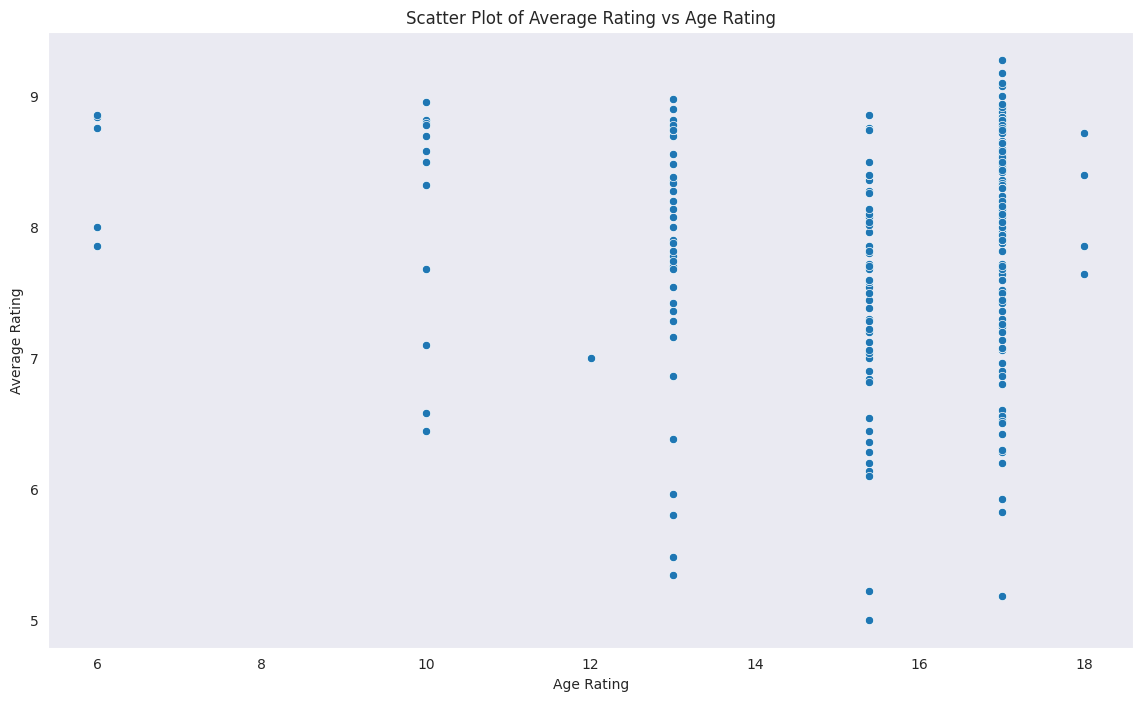

In [53]:
# age rating vs average rating corelation with scatter plot
plt.figure(figsize=(14, 8));

# lets have a temp df with nulls handled
df = games_df.copy()

# define imputers
impute_mean = SimpleImputer(strategy="mean")

# Replace zeros with np.nan for imputation
df["averageRating"].replace(0, np.nan, inplace=True)
df["ageRating"].replace(0, np.nan, inplace=True)

df["averageRating"] = impute_mean.fit_transform(df[["averageRating"]])
df["ageRating"] = impute_mean.fit_transform(df[["ageRating"]])

# now lets create the plot
plt.xlabel("Age Rating")
plt.ylabel("Average Rating")
plt.title("Scatter Plot of Average Rating vs Age Rating")
sns.scatterplot(x="ageRating" ,y = "averageRating" , data = df)

there is no relationship observed

In [54]:
# lets draw a pair plot of all numeric values , first lets drop non required columns
num_columns.drop(columns= [ "__v" ] , inplace=True)
num_columns.columns

Index(['averageRating', 'avgPlaytime', 'ageRating'], dtype='object')

In [55]:
# lets imput missing values for avgplay time
impute_mean = SimpleImputer(strategy="mean")
df["avgPlaytime"].replace(0, np.nan, inplace=True)
df["avgPlaytime"] = impute_mean.fit_transform(df[["avgPlaytime"]])


/tmp/ipython-input-840260952.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["avgPlaytime"].replace(0, np.nan, inplace=True)


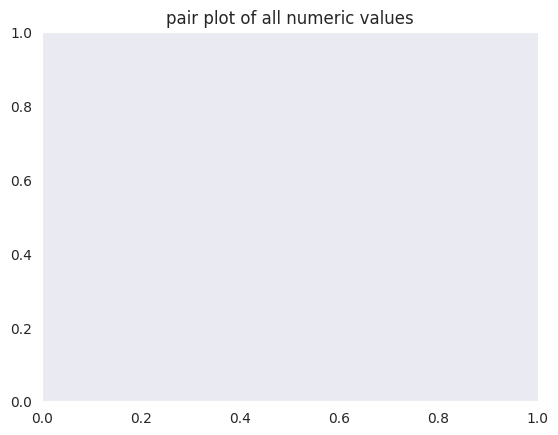

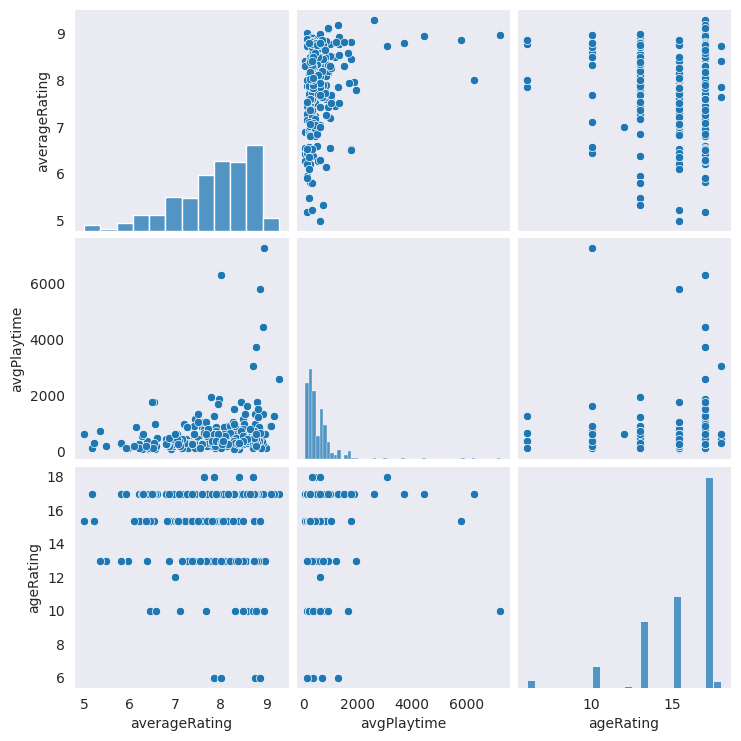

In [60]:

# lets now plot the pair plot
plt.title("pair plot of all numeric values")
sns.pairplot( df[num_columns.columns])

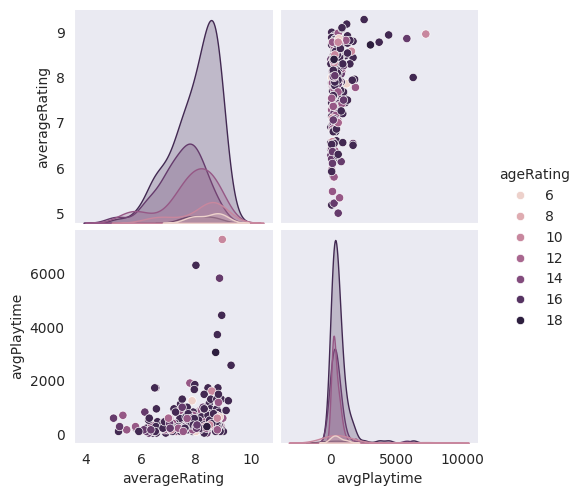

In [61]:
# with age as hue
sns.pairplot( df[num_columns.columns] , hue= "ageRating")

Text(0.5, 1.0, 'Correlation Heatmap numeric data')

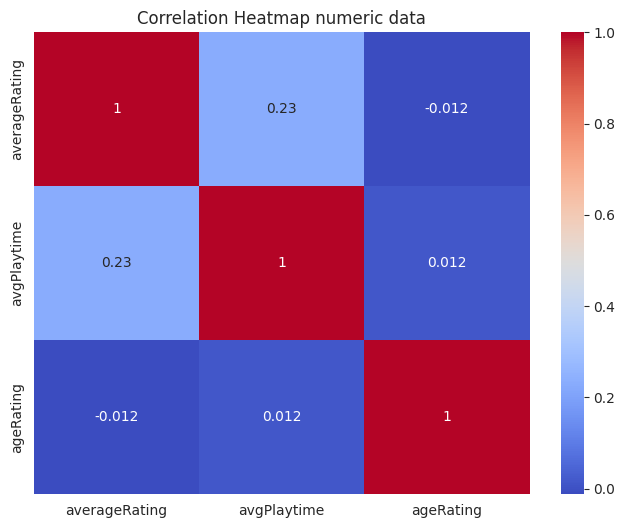

In [62]:
# lets plot a corr realtion heat map

corr_matrix = df[num_columns.columns].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap numeric data")

no strong relational data found .

# Data cleaning

now lets clear all the unwanted data from the data frame as per our observation and also impute missing values .

In [63]:
games_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   _id             261 non-null    object             
 1   title           261 non-null    object             
 2   description     261 non-null    object             
 3   averageRating   261 non-null    float64            
 4   genre           261 non-null    object             
 5   releaseDate     261 non-null    datetime64[ns, UTC]
 6   posterUrl       261 non-null    object             
 7   backdropUrl     261 non-null    object             
 8   isActive        261 non-null    bool               
 9   status          261 non-null    object             
 10  platforms       261 non-null    object             
 11  avgPlaytime     246 non-null    float64            
 12  developer       261 non-null    object             
 13  youtubeVideoId  261 non-null    obj

In [64]:
# lets create a copy of the data
df_clean = games_df.copy()

#lets remove any inactive games before procceding further
df_clean = df_clean[df_clean["isActive"] == True]

# lest first define all the columns to drop
columns_to_drop = [
    '__v',           # MongoDB version key mot importent
    'updatedAt',     # Not needed for training
    'backdropUrl',   # URL - not useful for training
    'posterUrl',     # URL - not useful for training
    'isActive',      # We only want active data
    'youtubeVideoId',# Video ID - not useful for training
    "createdAt",     # not important data can be misleading
]

# drop all the columsn
df_clean = df_clean.drop(columns= columns_to_drop)
print(f"Shape before dropping: {df_clean.shape}")
print(f"Shape after dropping: {df_clean.shape}")

Shape before dropping: (257, 11)
Shape after dropping: (257, 11)


In [65]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 257 entries, 0 to 260
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   _id            257 non-null    object             
 1   title          257 non-null    object             
 2   description    257 non-null    object             
 3   averageRating  257 non-null    float64            
 4   genre          257 non-null    object             
 5   releaseDate    257 non-null    datetime64[ns, UTC]
 6   status         257 non-null    object             
 7   platforms      257 non-null    object             
 8   avgPlaytime    246 non-null    float64            
 9   developer      257 non-null    object             
 10  ageRating      205 non-null    float64            
dtypes: datetime64[ns, UTC](1), float64(3), object(7)
memory usage: 24.1+ KB


lets take care of numeric value having missing data

In [69]:
# lets replace 0 with nan for averageRating , ageRating , avgPlaytime
# since in our application this are equilant to nan

df_clean["averageRating"].replace(0, np.nan, inplace=True)
df_clean["ageRating"].replace(0, np.nan, inplace=True)
df_clean["avgPlaytime"].replace(0, np.nan, inplace=True)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 257 entries, 0 to 260
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   _id            257 non-null    object             
 1   title          257 non-null    object             
 2   description    257 non-null    object             
 3   averageRating  256 non-null    float64            
 4   genre          257 non-null    object             
 5   releaseDate    257 non-null    datetime64[ns, UTC]
 6   status         257 non-null    object             
 7   platforms      257 non-null    object             
 8   avgPlaytime    246 non-null    float64            
 9   developer      257 non-null    object             
 10  ageRating      202 non-null    float64            
dtypes: datetime64[ns, UTC](1), float64(3), object(7)
memory usage: 24.1+ KB


/tmp/ipython-input-828503176.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean["averageRating"].replace(0, np.nan, inplace=True)
/tmp/ipython-input-828503176.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [73]:
# lets set up imputer
imputer_mean = SimpleImputer(strategy="mean")

# impute only necessary columns
df_clean[["averageRating" , "ageRating" , "avgPlaytime"]] = imputer_mean.fit_transform(df_clean[["averageRating" , "ageRating" , "avgPlaytime"]])

In [74]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 257 entries, 0 to 260
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   _id            257 non-null    object             
 1   title          257 non-null    object             
 2   description    257 non-null    object             
 3   averageRating  257 non-null    float64            
 4   genre          257 non-null    object             
 5   releaseDate    257 non-null    datetime64[ns, UTC]
 6   status         257 non-null    object             
 7   platforms      257 non-null    object             
 8   avgPlaytime    257 non-null    float64            
 9   developer      257 non-null    object             
 10  ageRating      257 non-null    float64            
dtypes: datetime64[ns, UTC](1), float64(3), object(7)
memory usage: 24.1+ KB


In [76]:
# lest check if we have any null
null_counts = df_clean[num_columns.columns].isnull().sum()
null_counts

,0
averageRating,0
avgPlaytime,0
ageRating,0


In [77]:
# lets now handle any missing data in release date

# currently we dont have any missing value but it can be there in future
# lets imput this with median()
median_date = df_clean['releaseDate'].median()
df_clean['releaseDate'] = df_clean['releaseDate'].fillna(median_date)
df_clean['releaseDate'].isnull().sum()

np.int64(0)

Now lets go on and deal with missing values in our array type feilds in case they are toatlly missing or an empty array lest fill them up by unknown . and add a feild with IsMissing and set to true

In [78]:
# for doing this lets create a function since we have a lot of columns
def impute_array_col (df , col_name , fill_value = ["Unknown"]):
  # impute the missing values first
  filled_col = df[col_name].apply(lambda x: x if isinstance(x , list) and len(x) > 0 else fill_value)
  # create a flag column for missing data
  flag_col = df[col_name].apply(lambda x : not isinstance(x , list) or len(x) == 0)
  # assign it back to the main dataframe
  df[col_name] = filled_col
  df[col_name + "IsMissing"] = flag_col
  return df

In [79]:
# lets check our categorical columns
cat_cols = df_clean.select_dtypes(include="object")
cat_cols.columns

Index(['_id', 'title', 'description', 'genre', 'status', 'platforms',
       'developer'],
      dtype='object')

In [80]:
# lets only imput for necessary cols
impute_array_col(df = df_clean , col_name = "genre");
impute_array_col(df = df_clean , col_name = "developer");
impute_array_col(df = df_clean , col_name = "platforms");

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 257 entries, 0 to 260
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   _id                 257 non-null    object             
 1   title               257 non-null    object             
 2   description         257 non-null    object             
 3   averageRating       257 non-null    float64            
 4   genre               257 non-null    object             
 5   releaseDate         257 non-null    datetime64[ns, UTC]
 6   status              257 non-null    object             
 7   platforms           257 non-null    object             
 8   avgPlaytime         257 non-null    float64            
 9   developer           257 non-null    object             
 10  ageRating           257 non-null    float64            
 11  genreIsMissing      257 non-null    bool               
 12  developerIsMissing  257 non-null    bool 

In [81]:
# lets handle string values now and  we only have description that can be missing .
df_clean["description"] = df_clean["description"].apply(lambda x : x if x.strip() else "No description available")
df_clean["description"].info()

<class 'pandas.core.series.Series'>
Index: 257 entries, 0 to 260
Series name: description
Non-Null Count  Dtype 
--------------  ----- 
257 non-null    object
dtypes: object(1)
memory usage: 4.0+ KB


In [82]:
# lets handle outliers for avgplayTime other numeric fileds already ahave boundaries

Q1 = df_clean["avgPlaytime"].quantile(0.10)#first quartile)
Q3 = df_clean["avgPlaytime"].quantile(0.85)#third quartile

IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean["avgPlaytime"] = df_clean["avgPlaytime"].clip(lower= lower_bound , upper=upper_bound)

df_clean["avgPlaytime"].head()

,avgPlaytime
0,780.0
1,900.0
2,660.0
3,120.0
4,840.0


# Feature engineering